In [5]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

In [6]:
df1 = pd.read_csv("../dataset/train.csv")
X_train = df1.drop(columns = ['Churn'])
y_train = df1['Churn'].values
df2 = pd.read_csv("../dataset/test.csv")
X_test = df2.drop(columns = ['Churn'])
y_test = df2['Churn'].values

In [7]:
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
#train
dt_model.fit(X_train, y_train)
#test
y_pred_dt = dt_model.predict(X_test)

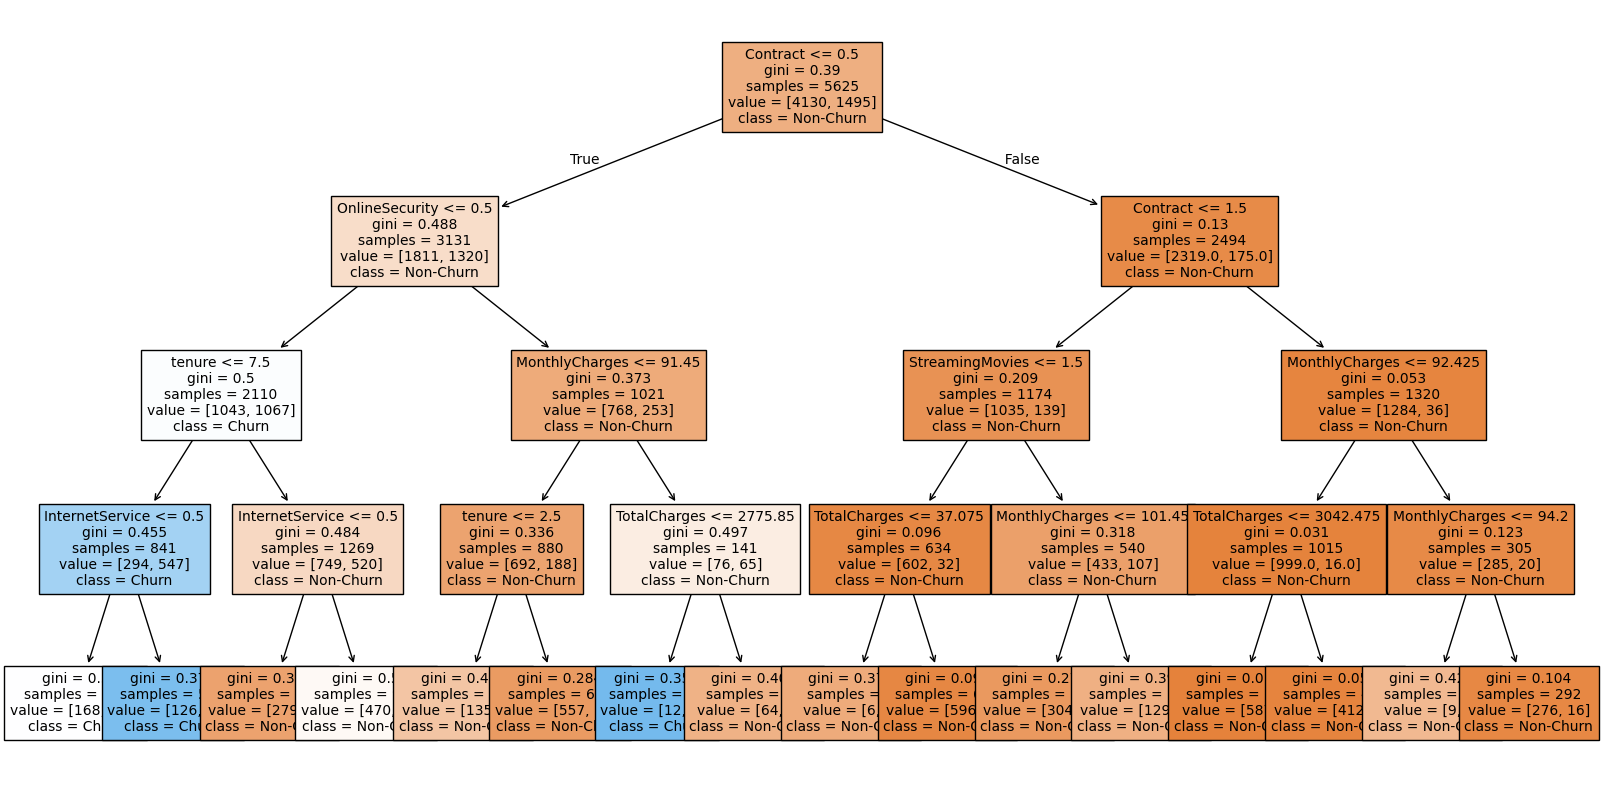

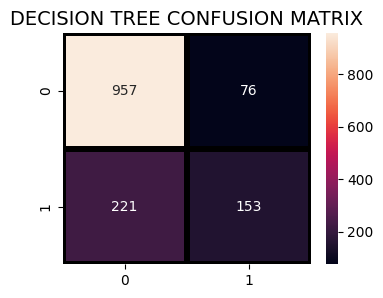

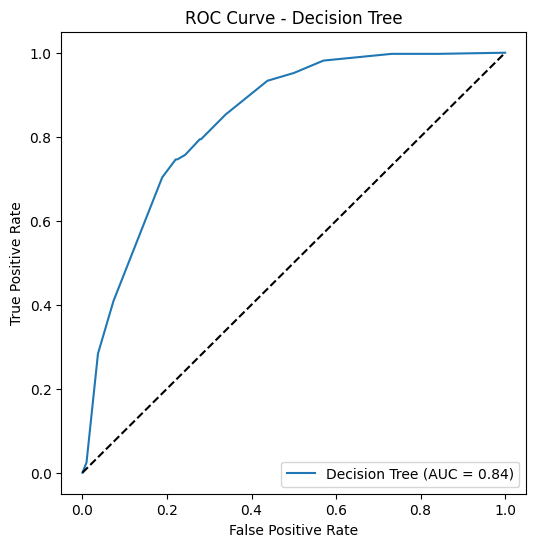

In [8]:
#visualize tree
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X_train.columns, class_names=["Non-Churn","Churn"], filled=True, fontsize=10)
plt.show()

#confusion mt and ROC curve
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title("DECISION TREE CONFUSION MATRIX",fontsize=14)
plt.show()

y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)
plt.figure(figsize=(6,6))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend(loc="lower right")
plt.show()

Upgrade Decision Tree model

1. Lowering threshold (~ 0.3)

In [9]:
dt_thresh = DecisionTreeClassifier(max_depth=4, random_state=42)

dt_thresh.fit(X_train, y_train)

y_prob_thresh = dt_thresh.predict_proba(X_test)[:, 1]
y_pred_thresh = (y_prob_thresh > 0.3).astype(int)

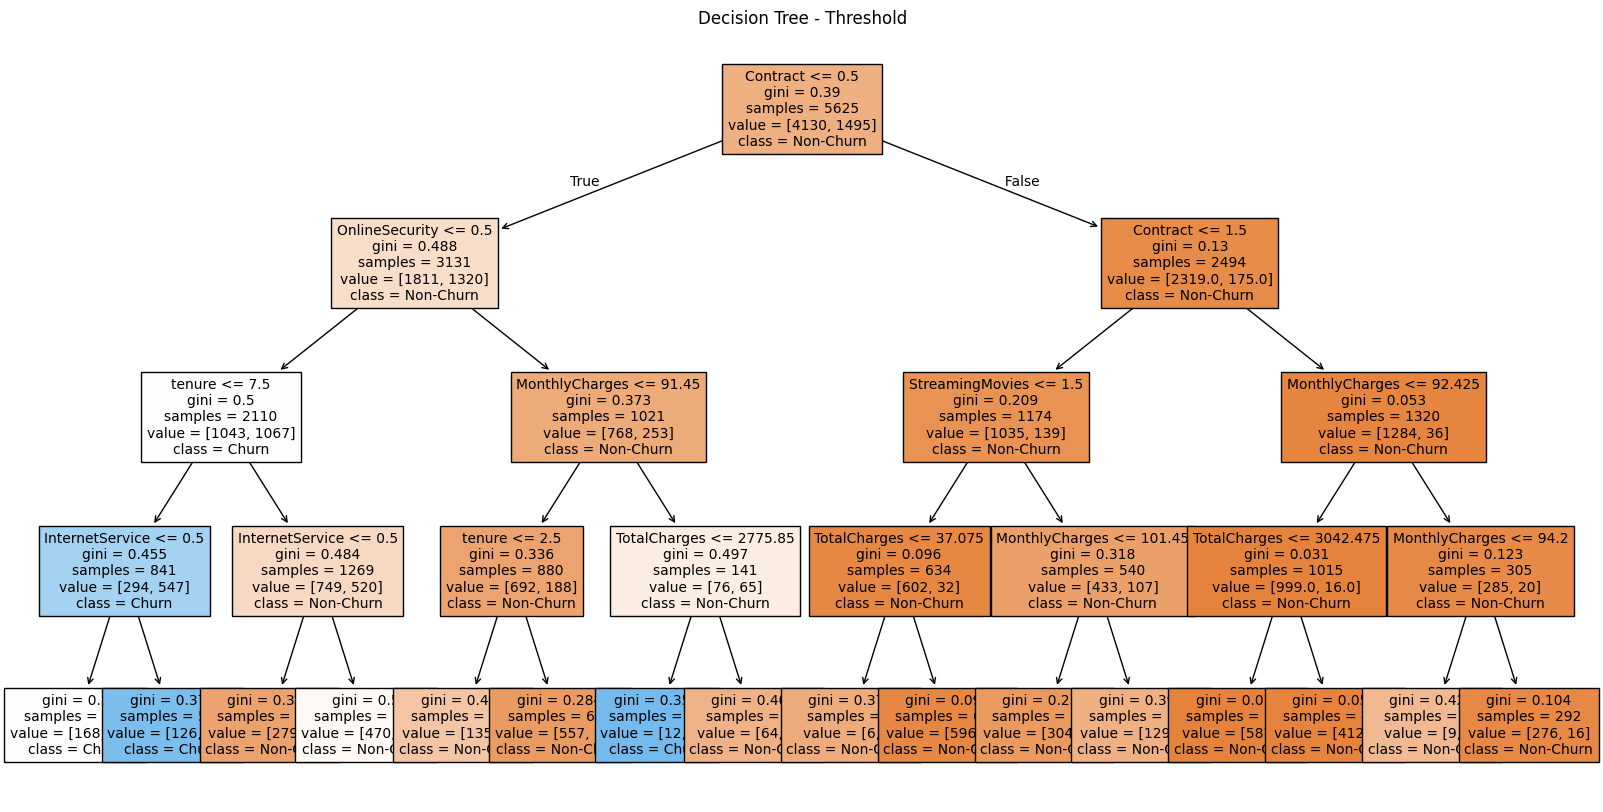

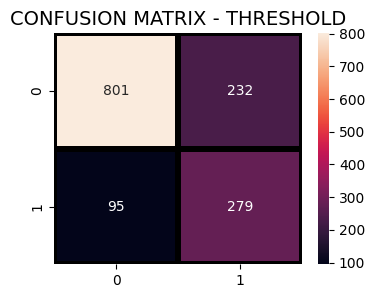

In [10]:
# tree
plt.figure(figsize=(20,10))
plot_tree(dt_thresh, feature_names=X_train.columns,
          class_names=["Non-Churn","Churn"],
          filled=True, fontsize=10)
plt.title("Decision Tree - Threshold")
plt.show()

# confusion matrix
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_thresh),
            annot=True, fmt="d", linecolor="k", linewidths=3)
plt.title("CONFUSION MATRIX - THRESHOLD", fontsize=14)
plt.show()

2. Handle Class Imbalance

In [11]:
dt_balanced = DecisionTreeClassifier(
    max_depth=4,
    class_weight='balanced',
    random_state=42
)

dt_balanced.fit(X_train, y_train)

y_pred_balanced = dt_balanced.predict(X_test)

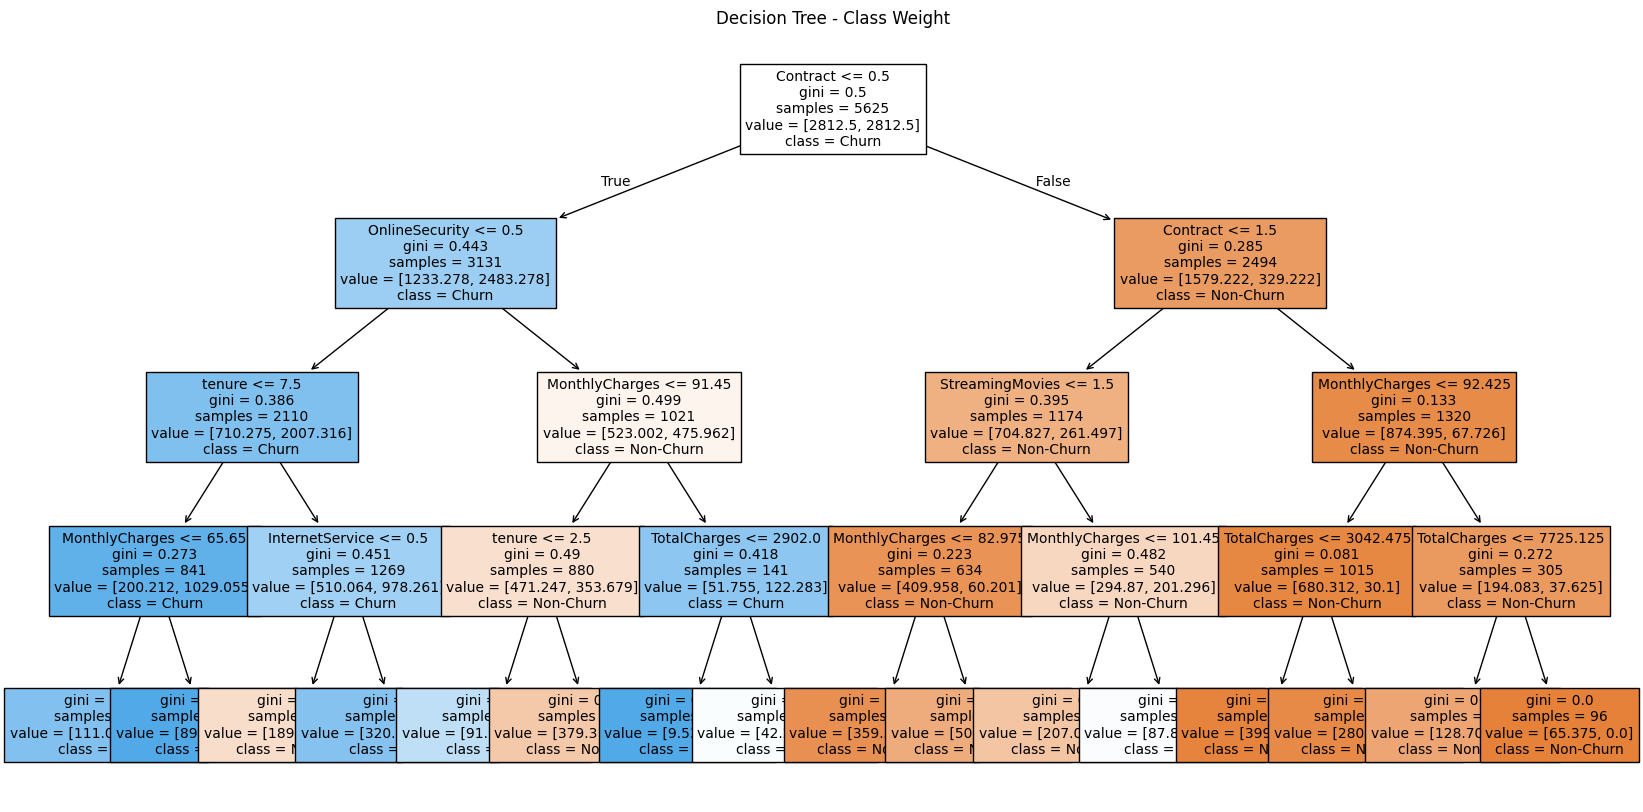

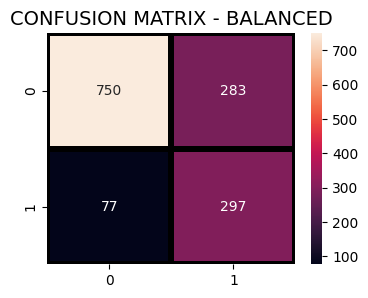

In [12]:
plt.figure(figsize=(20,10))
plot_tree(dt_balanced, feature_names=X_train.columns,
          class_names=["Non-Churn","Churn"],
          filled=True, fontsize=10)
plt.title("Decision Tree - Class Weight")
plt.show()

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_balanced),
            annot=True, fmt="d", linecolor="k", linewidths=3)
plt.title("CONFUSION MATRIX - BALANCED", fontsize=14)
plt.show()

4. Limit Tree Complexity

In [13]:
dt_limited = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    random_state=42
)

dt_limited.fit(X_train, y_train)

y_pred_limited = dt_limited.predict(X_test)

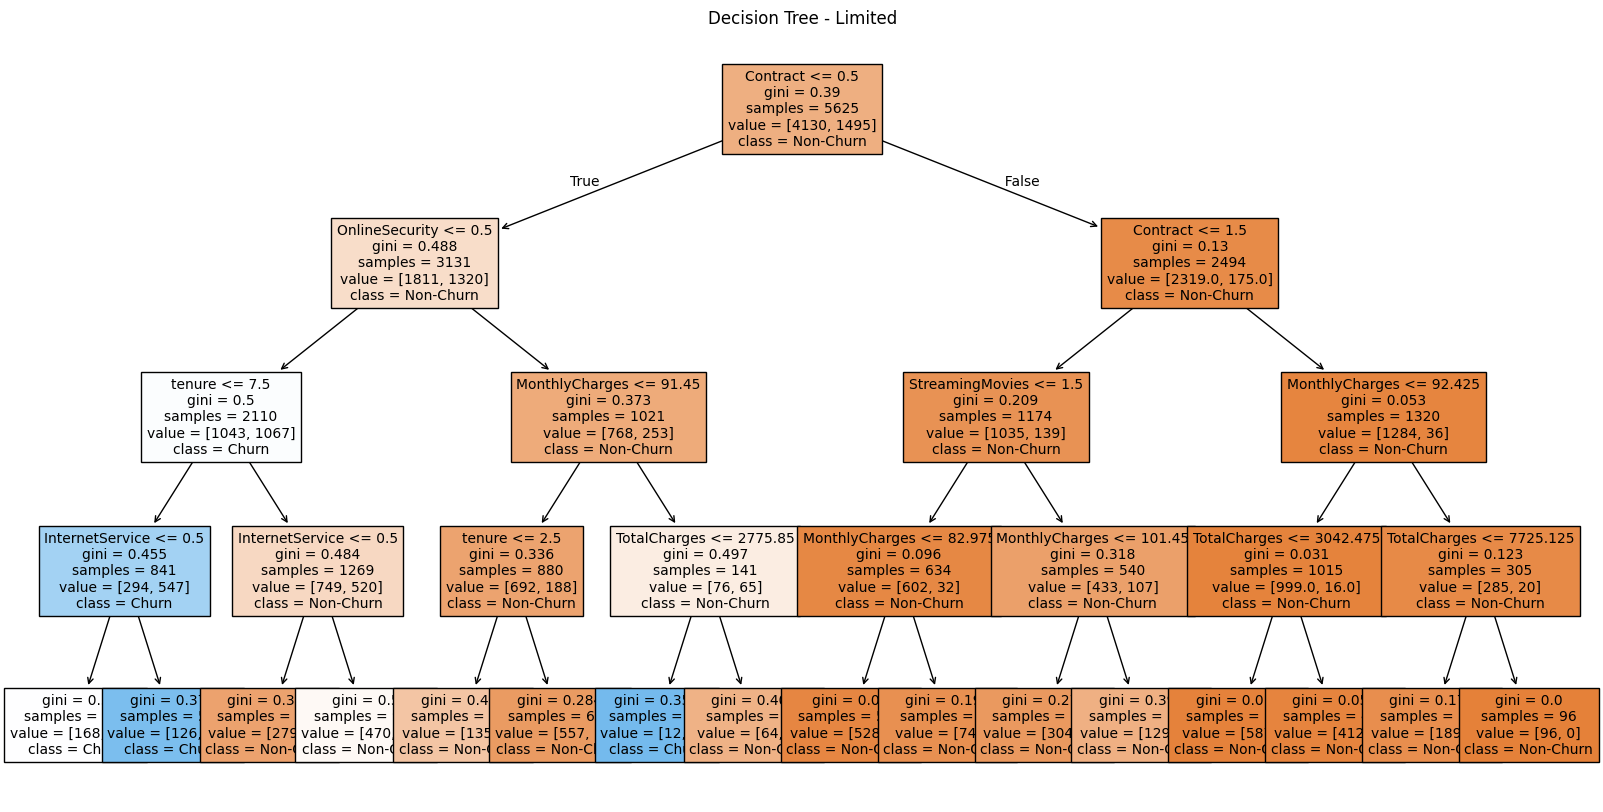

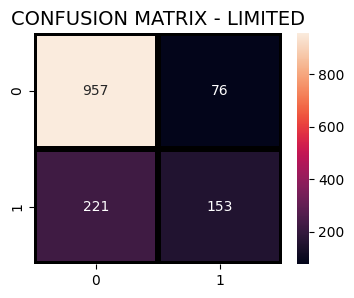

In [14]:
plt.figure(figsize=(20,10))
plot_tree(dt_limited, feature_names=X_train.columns,
          class_names=["Non-Churn","Churn"],
          filled=True, fontsize=10)
plt.title("Decision Tree - Limited")
plt.show()

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_limited),
            annot=True, fmt="d", linecolor="k", linewidths=3)
plt.title("CONFUSION MATRIX - LIMITED", fontsize=14)
plt.show()

5. Apply Pruning

In [15]:
dt_pruned = DecisionTreeClassifier(
    max_depth=4,
    ccp_alpha=0.01,
    random_state=42
)

dt_pruned.fit(X_train, y_train)

y_pred_pruned = dt_pruned.predict(X_test)

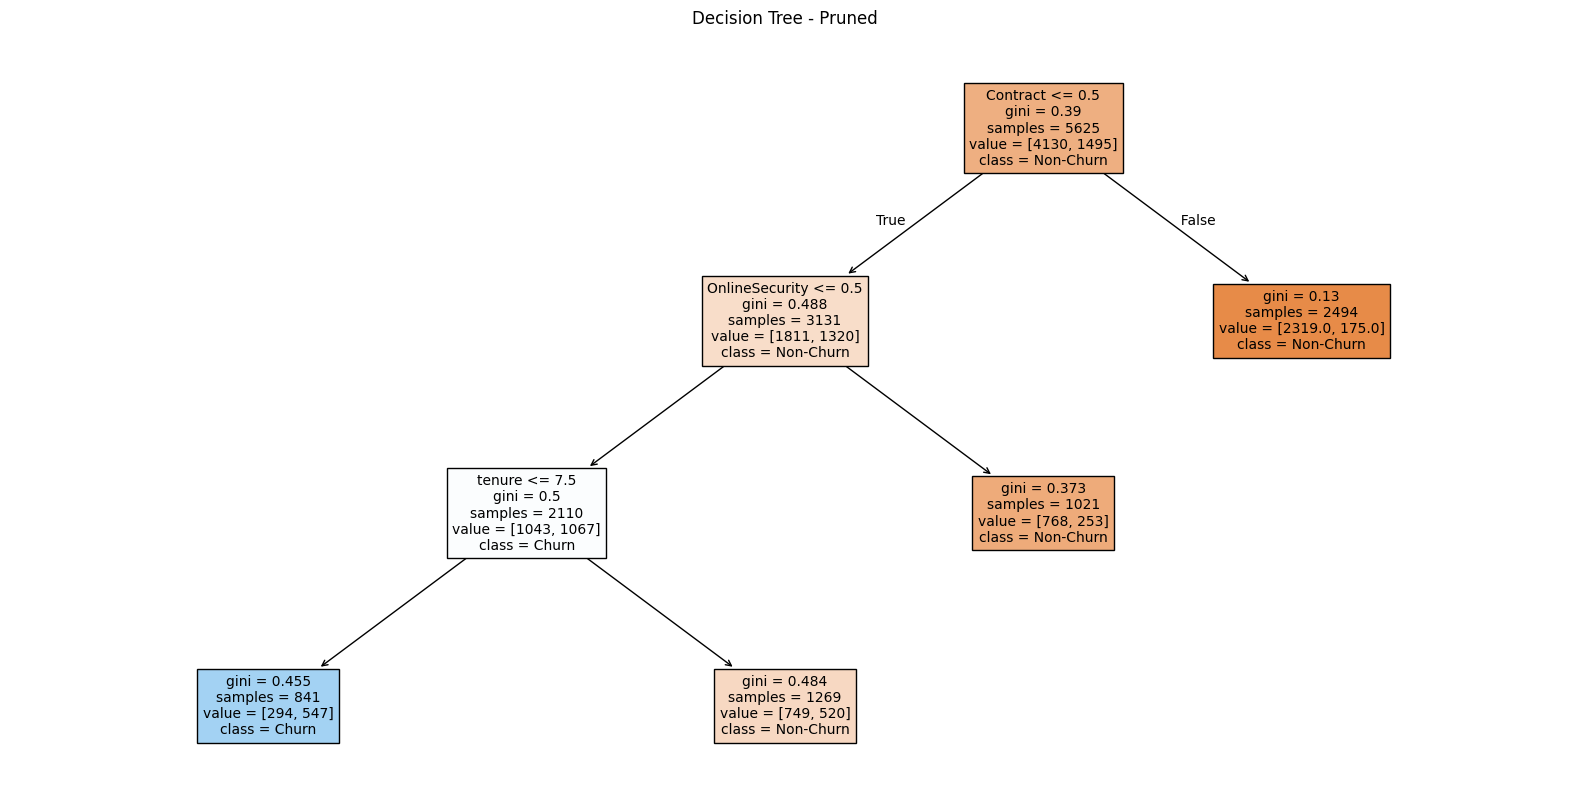

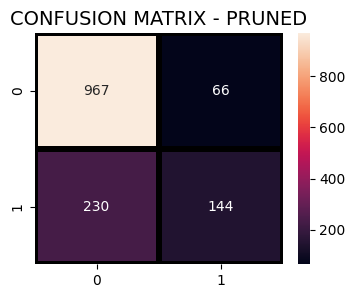

In [16]:
plt.figure(figsize=(20,10))
plot_tree(dt_pruned, feature_names=X_train.columns,
          class_names=["Non-Churn","Churn"],
          filled=True, fontsize=10)
plt.title("Decision Tree - Pruned")
plt.show()

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_pruned),
            annot=True, fmt="d", linecolor="k", linewidths=3)
plt.title("CONFUSION MATRIX - PRUNED", fontsize=14)
plt.show()

6. Final confusion matrix and evaluation metrics summary

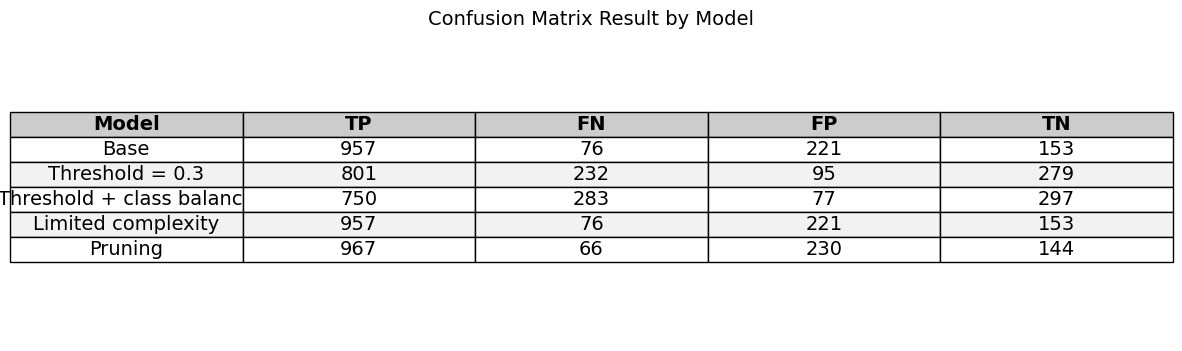

In [ ]:
data = {
    "Model": [
        "Base",
        "Threshold = 0.3",
        "Threshold + class balance",
        "Limited complexity",
        "Pruning"
    ],
    "TP": [957, 801, 750, 957, 967],
    "FN": [76, 232, 283, 76, 66],
    "FP": [221, 95, 77, 221, 230],
    "TN": [153, 279, 297, 153, 144]
}

df = pd.DataFrame(data)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.5, 1.5)

for (row, col), cell in table.get_celld().items():
    if row == 0:  # header
        cell.set_facecolor("#cccccc")
        cell.set_text_props(weight='bold', color='black')
    else:
        cell.set_facecolor("#f2f2f2" if row % 2 == 0 else "#ffffff")

plt.title("Confusion Matrix Result by Model", fontsize=14)
plt.show()

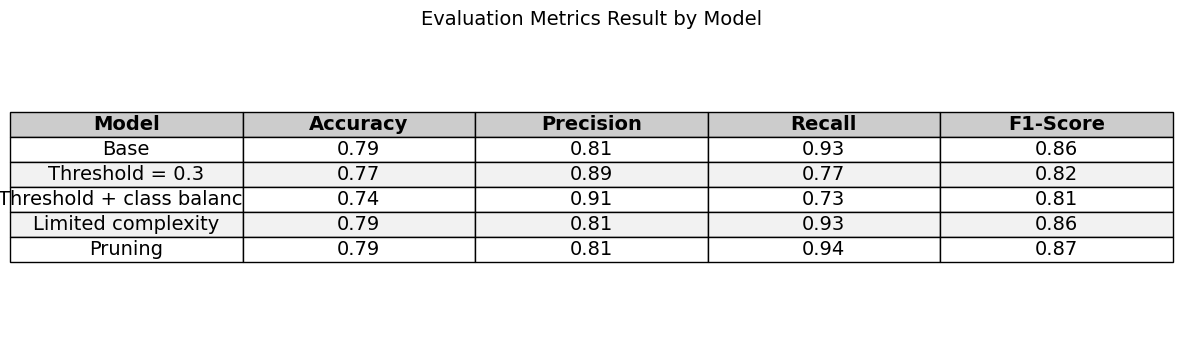

In [22]:
data = {
    "Model": [
        "Base",
        "Threshold = 0.3",
        "Threshold + class balance",
        "Limited complexity",
        "Pruning"
    ],
    "Accuracy": [0.79, 0.77, 0.74, 0.79, 0.79],
    "Precision": [0.81, 0.89, 0.91, 0.81, 0.81],
    "Recall": [0.93, 0.77, 0.73, 0.93, 0.94],
    "F1-Score": [0.86, 0.82, 0.81, 0.86, 0.87]
}

df = pd.DataFrame(data)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.5, 1.5)

for (row, col), cell in table.get_celld().items():
    if row == 0:  # header
        cell.set_facecolor("#cccccc")
        cell.set_text_props(weight='bold', color='black')
    else:
        cell.set_facecolor("#f2f2f2" if row % 2 == 0 else "#ffffff")

plt.title("Evaluation Metrics Result by Model", fontsize=14)
plt.show()